In [1]:
import torch
!pip install matplotlib seaborn scikit-learn pillow
print(torch.__version__)

2.7.0


In [2]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
from torch.utils.data import random_split

os.makedirs("models", exist_ok=True)
os.makedirs("results", exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

trainset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
testset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_size = int(0.8 * len(trainset))
val_size = len(trainset) - train_size

train_dataset, val_dataset = random_split(trainset, [train_size, val_size])

trainloader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
valloader = torch.utils.data.DataLoader(val_dataset, batch_size=64, shuffle=False)

testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

print("Training images:", len(trainset))
print("Test images:", len(testset))

Training images: 60000
Test images: 10000


In [4]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.model(x)

model = MLP().to(device)
print(model)

MLP(
  (model): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=10, bias=True)
  )
)


In [23]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 5
train_losses = []
val_losses = []
test_accuracies = []

for epoch in range(epochs):
    model.train()
    running_loss = 0

    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for images, labels in valloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

    val_loss /= len(valloader)
    val_losses.append(val_loss)

    model.train() 

    avg_loss = running_loss / len(trainloader)
    train_losses.append(avg_loss)

    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    test_accuracies.append(accuracy)

    print(f"Epoch {epoch+1}, Train Loss: {running_loss/len(trainloader):.4f}, Val Loss: {val_loss:.4f}, Accuracy: {accuracy:.2f}%")

Epoch 1, Train Loss: 0.0966, Val Loss: 0.1185, Accuracy: 96.68%
Epoch 2, Train Loss: 0.0833, Val Loss: 0.0997, Accuracy: 96.71%
Epoch 3, Train Loss: 0.0728, Val Loss: 0.1243, Accuracy: 96.56%
Epoch 4, Train Loss: 0.0649, Val Loss: 0.1183, Accuracy: 96.38%
Epoch 5, Train Loss: 0.0599, Val Loss: 0.0912, Accuracy: 97.04%


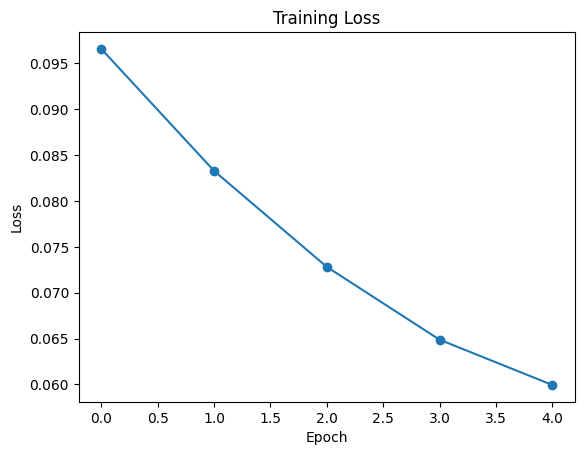

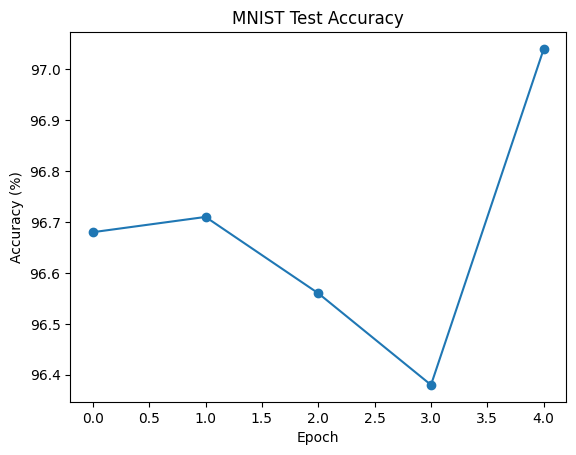

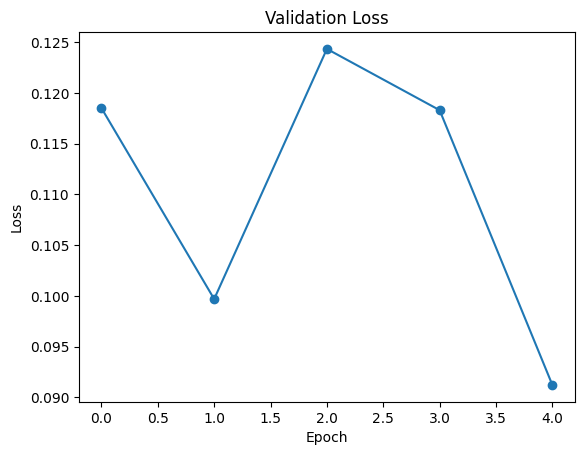

In [24]:
torch.save(model.state_dict(), "models/mlp_model.pth")

plt.figure()
plt.plot(train_losses, marker="o")
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.savefig("results/loss.png")
plt.show()

plt.figure()
plt.plot(test_accuracies, marker="o")
plt.title("MNIST Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.savefig("results/accuracy.png")
plt.show()

plt.figure()
plt.plot(val_losses, marker="o")
plt.title("Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.savefig("results/Validation.png")
plt.show()

In [25]:
images, labels = next(iter(testloader))
images, labels = images.to(device), labels.to(device)

model.eval()
with torch.no_grad():
    outputs = model(images)
    _, predicted = torch.max(outputs, 1)

print("Actual:   ", labels[:10].cpu().numpy())
print("Predicted:", predicted[:10].cpu().numpy())

Actual:    [7 2 1 0 4 1 4 9 5 9]
Predicted: [7 2 1 0 4 1 4 9 5 9]


In [26]:
custom_path = "Handwritten-Digits-Spring-2026/digits"

In [27]:
images = []
labels = []
group_ids = []

for file in os.listdir(custom_path):
    if file.endswith(".png"):
        label = int(file.split("-")[0])
        group_id = int(file.split("-")[1])
        img_path = os.path.join(custom_path, file)

        img = Image.open(img_path).convert("L")
        img = img.resize((28, 28))
        img = np.array(img)

        images.append(img)
        labels.append(label)
        group_ids.append(group_id)

images = np.array(images)
labels = np.array(labels)
group_ids = np.array(group_ids)


In [28]:
images = images / 255.0
images = (images - 0.5) / 0.5
images = images.reshape(-1, 1, 28, 28)

images_tensor = torch.tensor(images, dtype=torch.float32).to(device)
labels_tensor = torch.tensor(labels, dtype=torch.long).to(device)

In [30]:
model.eval()

with torch.no_grad():
    outputs = model(images_tensor)
    _, predicted = torch.max(outputs, 1)

correct = (predicted == labels_tensor).sum().item()
total = labels_tensor.size(0)
accuracy = 100 * correct / total

print(f"\nHandwritten Digit Accuracy: {accuracy:.2f}%")

pred_np = predicted.cpu().numpy()
labels_np = labels_tensor.cpu().numpy()

print("\nAccuracy Per Group:")

for group in sorted(np.unique(group_ids)):
    mask = group_ids == group

    group_correct = (pred_np[mask] == labels_np[mask]).sum()
    group_total = mask.sum()
    group_accuracy = 100 * group_correct / group_total

    print(f"Group {group}: {group_accuracy:.2f}% ({group_correct}/{group_total})")


Handwritten Digit Accuracy: 47.86%

Accuracy Per Group:
Group 1: 20.00% (4/20)
Group 2: 33.33% (10/30)
Group 3: 30.00% (12/40)
Group 4: 55.00% (11/20)
Group 5: 63.33% (19/30)
Group 6: 66.67% (20/30)
Group 7: 56.67% (17/30)
Group 8: 45.00% (18/40)
Group 9: 57.50% (23/40)


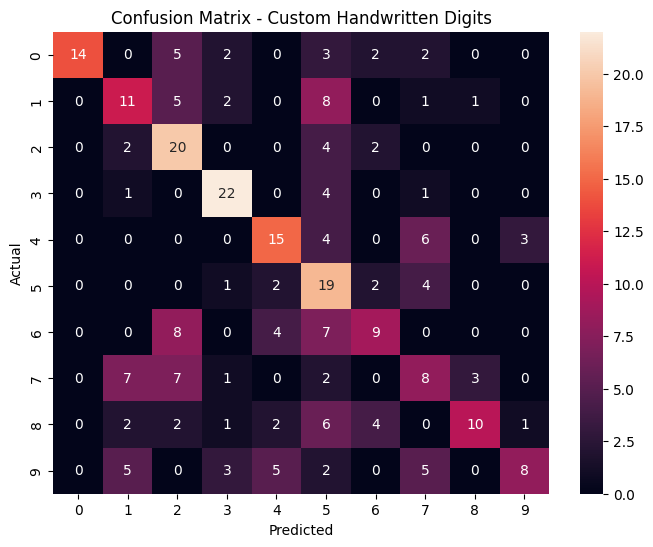

In [31]:
cm = confusion_matrix(
    custom_labels_tensor.cpu(),
    custom_predicted.cpu()
)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Custom Handwritten Digits")
plt.savefig("results/confusion_matrix.png")
plt.show()

In [32]:
print(classification_report(
    custom_labels_tensor.cpu(),
    custom_predicted.cpu()
))

              precision    recall  f1-score   support

           0       1.00      0.50      0.67        28
           1       0.39      0.39      0.39        28
           2       0.43      0.71      0.53        28
           3       0.69      0.79      0.73        28
           4       0.54      0.54      0.54        28
           5       0.32      0.68      0.44        28
           6       0.47      0.32      0.38        28
           7       0.30      0.29      0.29        28
           8       0.71      0.36      0.48        28
           9       0.67      0.29      0.40        28

    accuracy                           0.49       280
   macro avg       0.55      0.49      0.48       280
weighted avg       0.55      0.49      0.48       280

